Exploratory Data Analysis

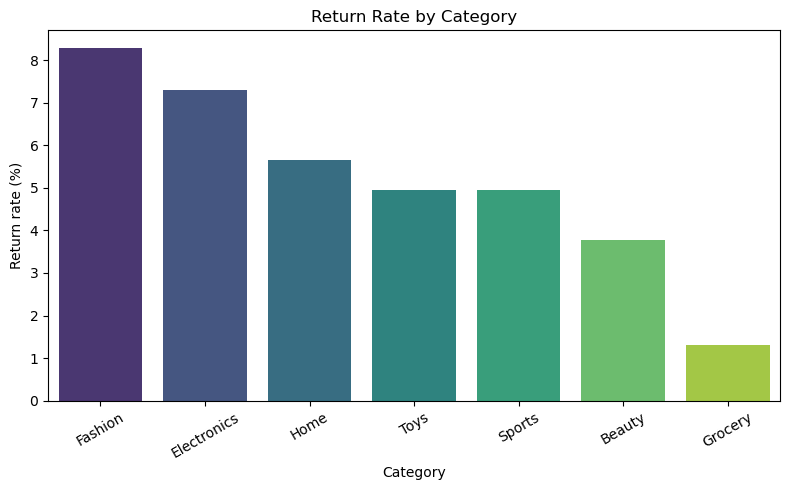

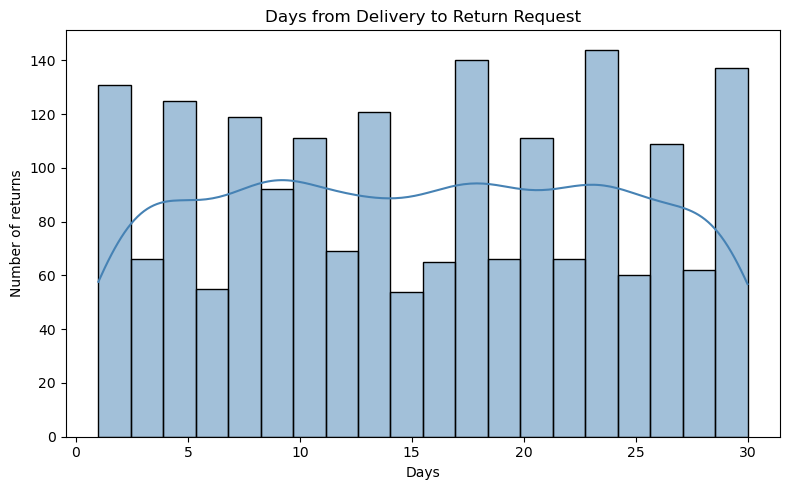

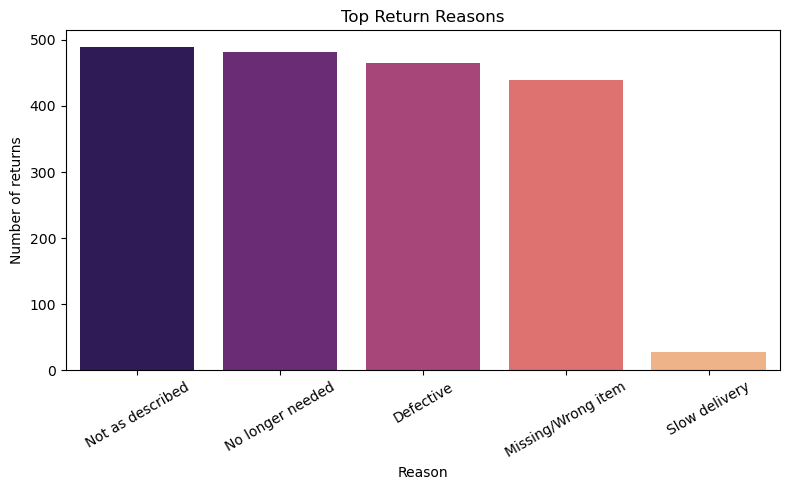

Return rate by category:
       category  return_rate_percent
2      Fashion             8.282699
1  Electronics             7.297735
4         Home             5.649718
6         Toys             4.944667
5       Sports             4.938864
0       Beauty             3.777724
3      Grocery             1.306062

Average days from delivery to return request: 15.468733578560169

Top return reasons:
                reason  count
0    Not as described    490
1    No longer needed    481
2           Defective    465
3  Missing/Wrong item    439
4       Slow delivery     28


In [4]:
# Phase 2: EDA - Return Analysis
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset from either the workspace root or notebook folder.
workspace_root = Path.cwd()
data_path = workspace_root / "cleaned_ecommerce_returns.csv"
if not data_path.exists():
    data_path = workspace_root.parent / "cleaned_ecommerce_returns.csv"

if not data_path.exists():
    raise FileNotFoundError("Run the Phase 1 data pipeline before running this notebook.")

df = pd.read_csv(data_path)
required_columns = {
    "category", "is_return", "returned", "delivered_date", "request_date", "return_reason"
}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

# Parse dates and restrict return-specific metrics to returned records.
for column in ["delivered_date", "request_date"]:
    df[column] = pd.to_datetime(df[column], errors="coerce")
returns = df[df["is_return"].eq(1)].copy()
returns["return_request_days"] = (
    returns["request_date"] - returns["delivered_date"]
).dt.days

# 1. Return rate by category.
return_rate = (
    df.groupby("category", as_index=False)["is_return"]
    .mean()
    .sort_values("is_return", ascending=False)
)
return_rate["return_rate_percent"] = return_rate["is_return"] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=return_rate, x="category", y="return_rate_percent", hue="category", legend=False, palette="viridis")
plt.title("Return Rate by Category")
plt.ylabel("Return rate (%)")
plt.xlabel("Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 2. Days between delivery and return request.
return_cycle = returns["return_request_days"].dropna()
plt.figure(figsize=(8, 5))
sns.histplot(return_cycle, bins=20, kde=True, color="steelblue")
plt.title("Days from Delivery to Return Request")
plt.xlabel("Days")
plt.ylabel("Number of returns")
plt.tight_layout()
plt.show()

# 3. Top return reasons, excluding the non-return placeholder.
top_reasons = (
    returns["return_reason"]
    .value_counts()
    .rename_axis("reason")
    .reset_index(name="count")
)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_reasons, x="reason", y="count", hue="reason", legend=False, palette="magma")
plt.title("Top Return Reasons")
plt.ylabel("Number of returns")
plt.xlabel("Reason")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 4. Summary statistics.
print("Return rate by category:\n", return_rate[["category", "return_rate_percent"]])
print("\nAverage days from delivery to return request:", return_cycle.mean())
print("\nTop return reasons:\n", top_reasons)